In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('penguins_lter.csv')

# Task 1


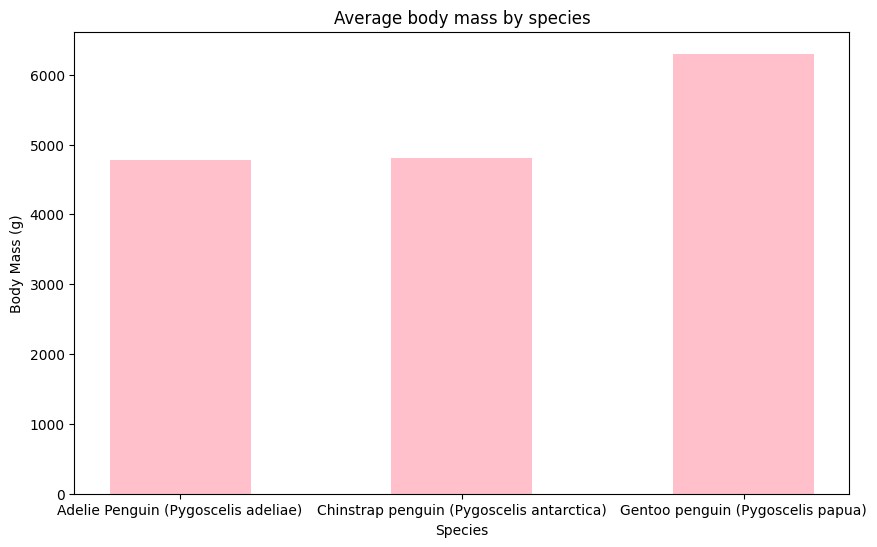

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(dataset["Species"], dataset["Body Mass (g)"], color='pink', width = 0.5)
plt.title('Average body mass by species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

# Task 2

In [3]:
# Calculate the average body mass per species for the bar charts
avg_body_mass_df = dataset.groupby('Species')['Body Mass (g)'].mean().reset_index()

display(avg_body_mass_df)

,Species,Body Mass (g)
0,Adelie Penguin (Pygoscelis adeliae),3700.662252
1,Chinstrap penguin (Pygoscelis antarctica),3733.088235
2,Gentoo penguin (Pygoscelis papua),5076.016260


/tmp/ipykernel_15554/481503949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x='Species', palette='PuRd')


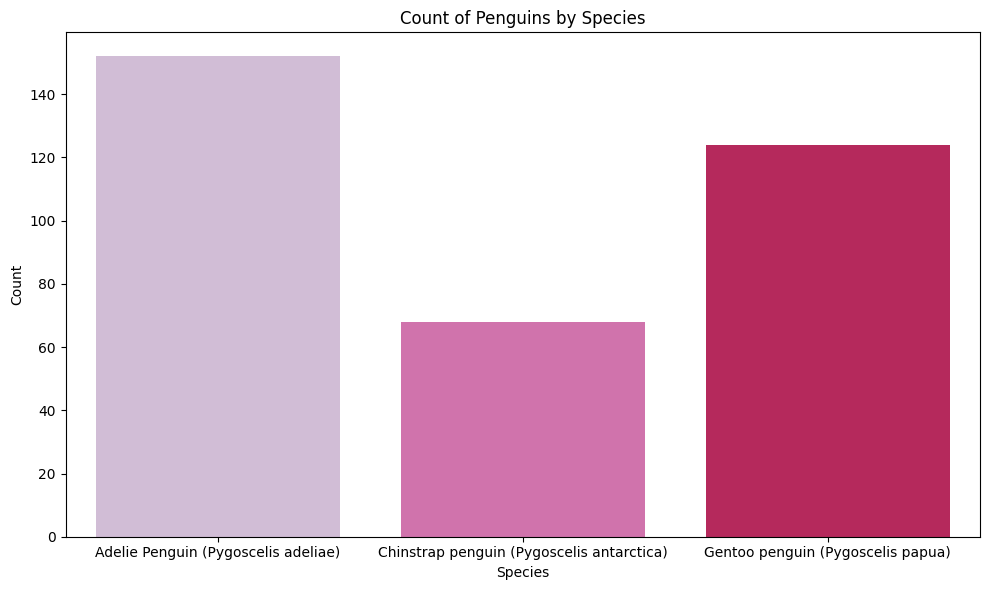

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x='Species', palette='PuRd')
plt.title('Count of Penguins by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The adelie penguin is the most common

# Task 3

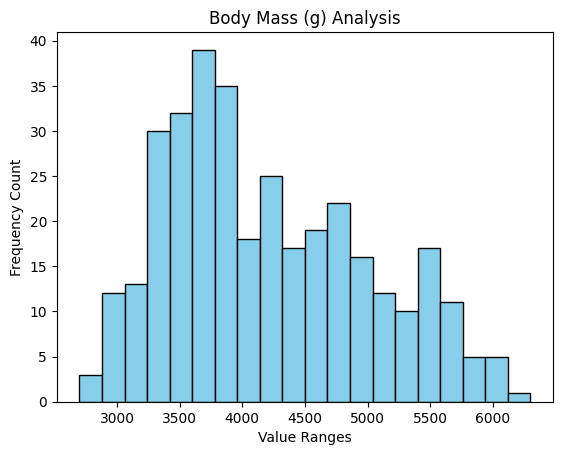

In [5]:
plt.hist( dataset["Body Mass (g)"], bins=20, color='skyblue', edgecolor='black')
plt.title('Body Mass (g) Analysis')
plt.xlabel('Value Ranges')
plt.ylabel('Frequency Count')
plt.show()

The dataset is right skewed

# Task 4

/tmp/ipykernel_15554/1932908406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='Species', y='Body Mass (g)', palette='PuRd')


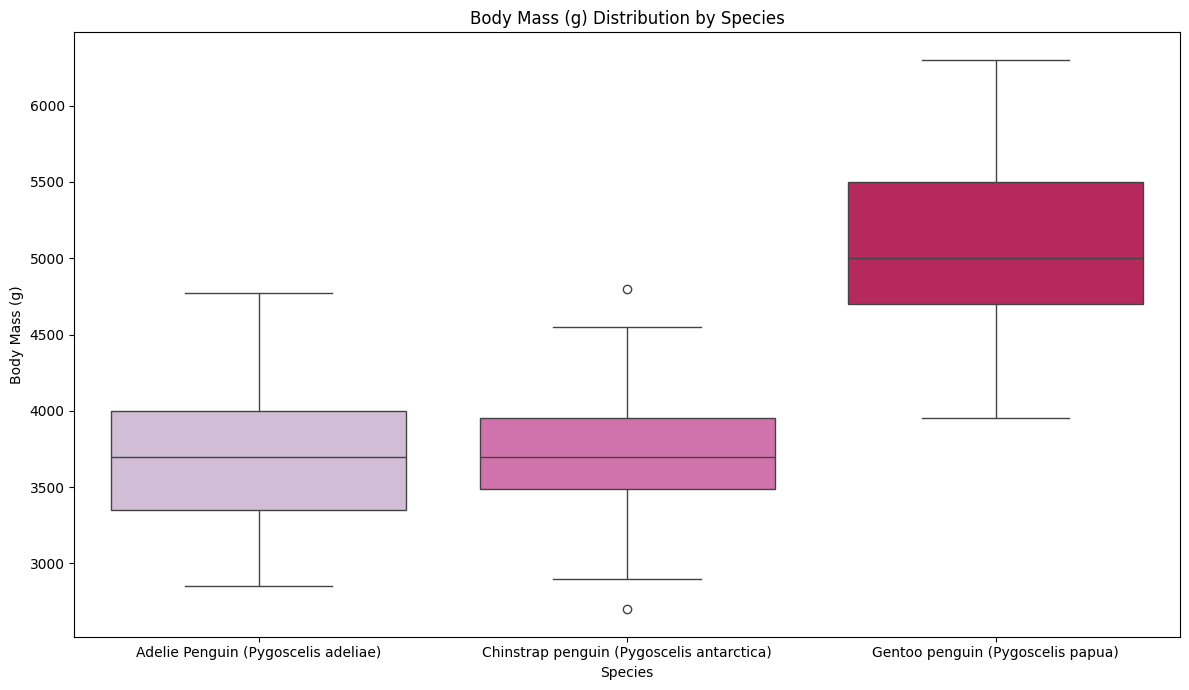

In [6]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=dataset, x='Species', y='Body Mass (g)', palette='PuRd')
plt.title('Body Mass (g) Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.tight_layout()
plt.show()

There are 2 outliers in the chinstrap penguin category

# Task 5

In [7]:
Q1 = dataset["Body Mass (g)"].quantile(0.25)
Q3 = dataset["Body Mass (g)"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = dataset[(dataset["Body Mass (g)"] < lower) | (dataset["Body Mass (g)"] > upper)]
print(len(outliers))

0


# Task 6

In [8]:
from scipy import stats
dataset["Body Mass (g)"] = stats.zscore(dataset["Body Mass (g)"])
outliers_z = dataset[dataset["Body Mass (g)"].abs() > 3]
print(len(outliers_z))

0


No because those are in terms of categories in species whereas this is in general data

# Task 7

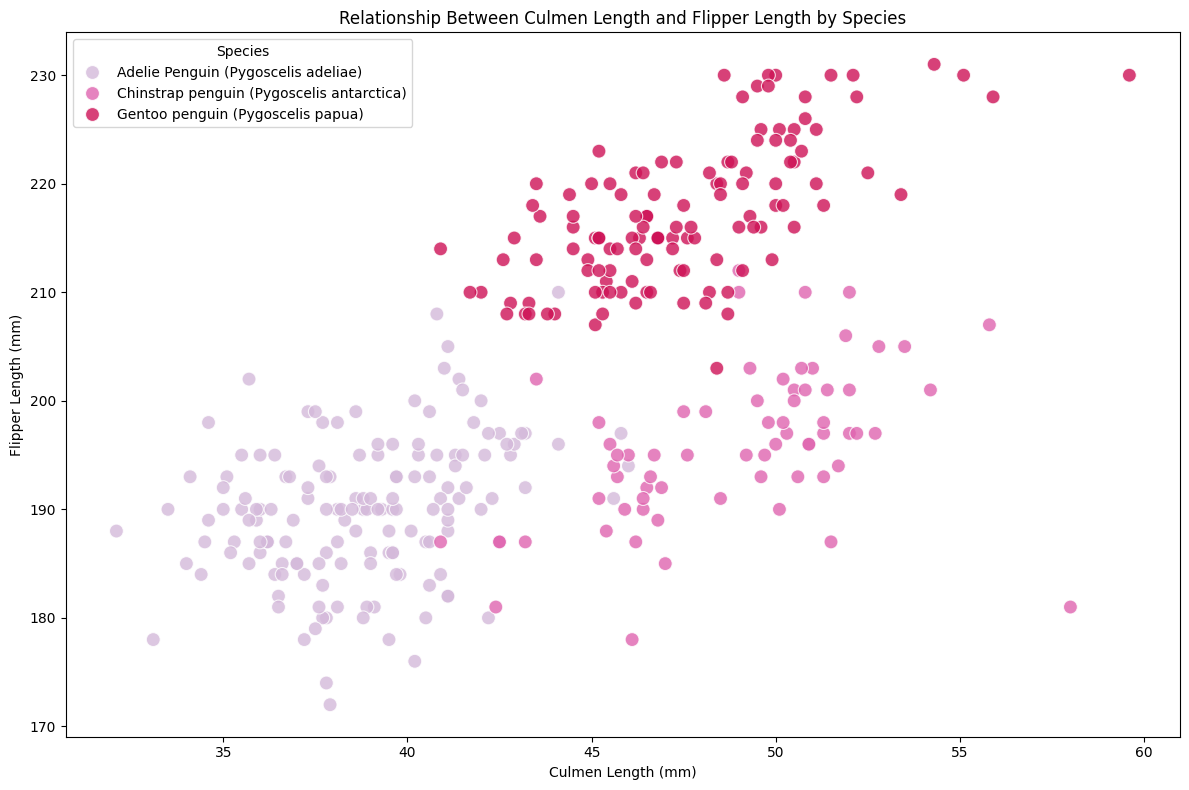

In [9]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=dataset, x='Culmen Length (mm)', y='Flipper Length (mm)', hue='Species', palette='PuRd', s=100, alpha=0.8)
plt.title('Relationship Between Culmen Length and Flipper Length by Species')
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()


# Task 8

/tmp/ipykernel_15554/2772481628.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_body_mass_by_culmen_bin = df_filtered.groupby('Culmen_Length_Bins')['Body Mass (g)'].mean().reset_index()


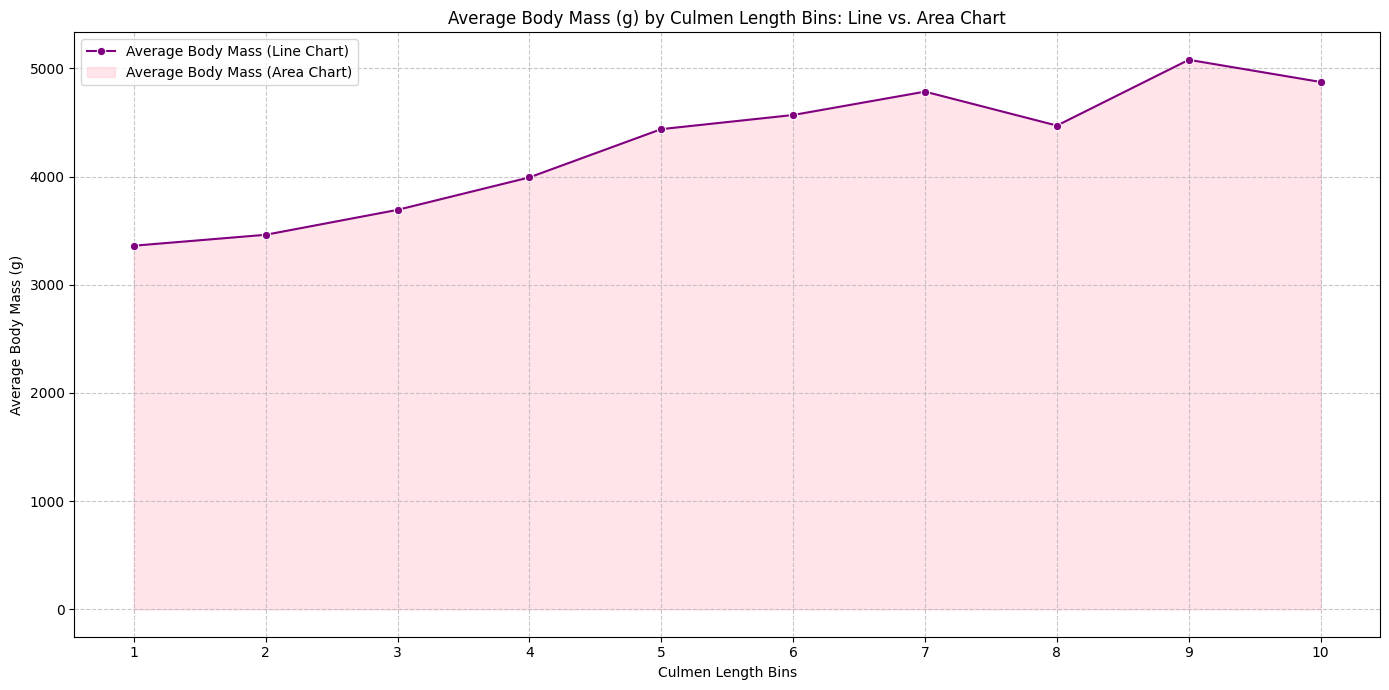

In [19]:
df_filtered = dataset.dropna(subset=['Culmen Length (mm)', 'Body Mass (g)']).copy()

# Create bins for 'Culmen Length (mm)'
df_filtered['Culmen_Length_Bins'] = pd.cut(df_filtered['Culmen Length (mm)'], bins=10, labels=[f'{i+1}' for i in range(10)], include_lowest=True)
df_filtered['Culmen_Length_Bins'] = pd.Categorical(df_filtered['Culmen_Length_Bins'], ordered=True)

# Calculate the average Body Mass
avg_body_mass_by_culmen_bin = df_filtered.groupby('Culmen_Length_Bins')['Body Mass (g)'].mean().reset_index()
avg_body_mass_by_culmen_bin['Culmen_Length_Bins_Numeric'] = avg_body_mass_by_culmen_bin['Culmen_Length_Bins'].astype(float)
avg_body_mass_by_culmen_bin = avg_body_mass_by_culmen_bin.sort_values(by='Culmen_Length_Bins_Numeric').drop(columns=['Culmen_Length_Bins_Numeric'])


plt.figure(figsize=(14, 7))
# Line Chart
sns.lineplot(x='Culmen_Length_Bins', y='Body Mass (g)', data=avg_body_mass_by_culmen_bin, marker='o', color='purple', label='Average Body Mass (Line Chart)')
# Area Chart
plt.fill_between( avg_body_mass_by_culmen_bin['Culmen_Length_Bins'].astype(str), avg_body_mass_by_culmen_bin['Body Mass (g)'], color='pink', alpha=0.4, label='Average Body Mass (Area Chart)')
plt.title('Average Body Mass (g) by Culmen Length Bins: Line vs. Area Chart')
plt.xlabel('Culmen Length Bins')
plt.ylabel('Average Body Mass (g)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

The filled area shows the grandness of it whereas the line shows the trend.

# Task 9

/tmp/ipykernel_15554/3125735548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='Body Mass (g)', data=avg_body_mass_df, palette='PuRd')


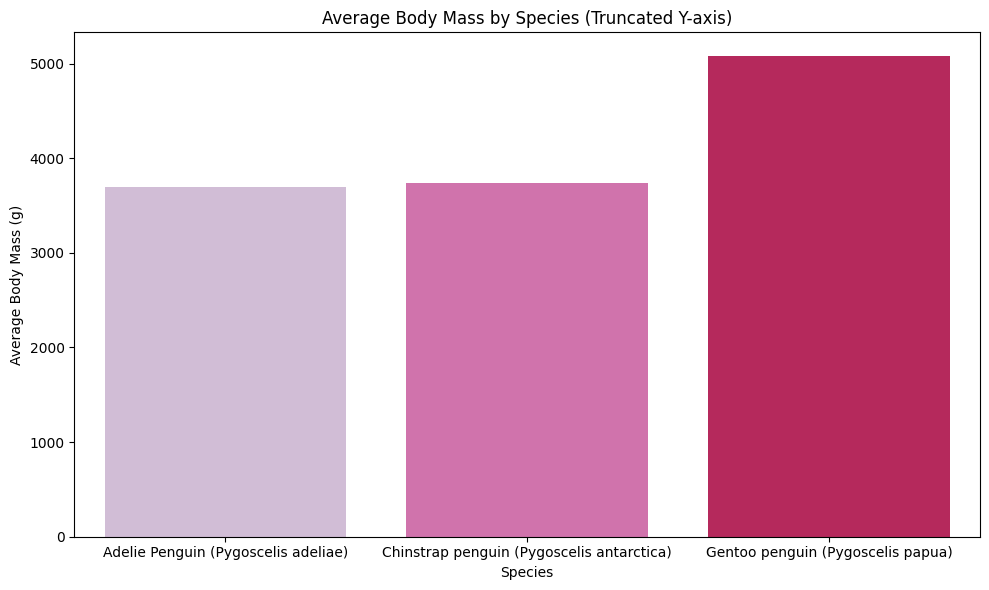

In [23]:
# Bar chart with y-axis starting at zero (original representation)
plt.figure(figsize=(10, 6))
sns.barplot(x='Species', y='Body Mass (g)', data=avg_body_mass_df, palette='PuRd')
plt.title('Average Body Mass by Species (Truncated Y-axis)')
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15554/230863973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='Body Mass (g)', data=avg_body_mass_df, palette='viridis')


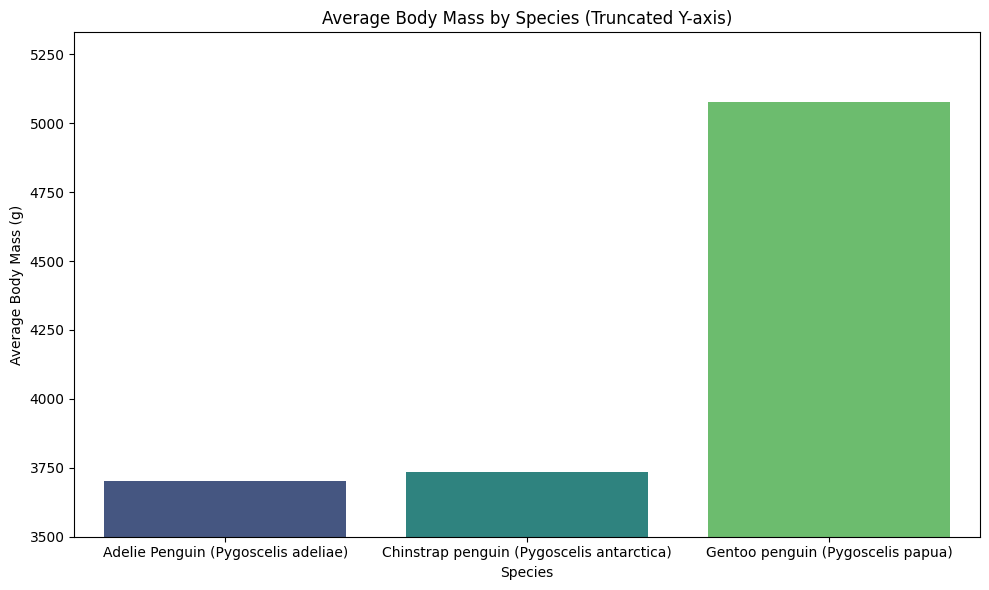

In [24]:
# Bar chart with truncated y-axis
plt.figure(figsize=(10, 6))
sns.barplot(x='Species', y='Body Mass (g)', data=avg_body_mass_df, palette='viridis')
plt.title('Average Body Mass by Species (Truncated Y-axis)')
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.ylim(bottom=3500)
plt.tight_layout()
plt.show()